# 컴퓨터 비전

### 담당교수 : 장원중

#### 그래프 한글이 깨질때 & 마이너스 부호 사용

In [1]:
import sys, os
from matplotlib import font_manager, rc 
import matplotlib.pyplot as plt

# 한글 폰트 설정 : 윈도우 폰트를 사용하는 경우 
# font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
# rc('font', family=font_name) 

# 운영체제별 한글 폰트 설정
if os.name == 'posix': # Mac 환경 폰트 설정
    rc('font', family='AppleGothic')
elif os.name == 'nt': # Windows 환경 폰트 설정
    rc('font', family='Malgun Gothic')

plt.rc('axes', unicode_minus=False) # 마이너스 폰트 설정

# 유니코드에서 음수 부호설정
rc('axes', unicode_minus=False)

# 부모 디렉터리의 파일을 가져올 수 있도록 설정
sys.path.append(os.pardir)     

# jupyter에서 matplotlib 그래프를 출력 영역에 표시  
%matplotlib inline 

# 레티나 설정 - 폰트 주변이 흐릿하게 보이는 것을 방지해 글씨가 좀 더 선명하게 보임
%config InlineBackend.figure_format = 'retina'

In [2]:
# 운영체제별 이름 

import platform

platform.system()

'Windows'

# 텐서플로 프로그램 기초

## 퍼셉트론 프로그래밍 

### OR 게이트

### (1) 가중치가 정해진 프로그램 

In [7]:
# 설정된 매개변수(가중치, 편향)로 퍼셉트론의 동작을 확인하는 프로그램 
# tensorflow의 Variable 함수로 퍼셉트론 구현 
# OR 게이트를 인식하는 프로그램 

import tensorflow as tf

# OR 데이터 구축
x = [[0.0,0.0],[0.0,1.0],[1.0,0.0],[1.0,1.0]]
y = [[-1],[1],[1],[1]]

# OR 분류 문제의 퍼셉트론 
#  - w : 가중치, b : 편향  
w = tf.Variable([[1.0],[1.0]])  
b = tf.Variable(-0.5)

# OR 분류 문제의 퍼셉트론 
s = tf.add(tf.matmul(x,w),b)   # 행렬 곱(tf.matmul) 
o = tf.sign(s)                 # (s > 0 : 1 , s <= 0 : -1)을 출력 

print(o)
#tf.Tensor(
#[[-1.]
# [ 1.]
# [ 1.]
# [ 1.]], shape=(4, 1), dtype=float32)

# 실행 결과 레이블 y와 동일한 값을 출력한 것을 알 수 있다. 

tf.Tensor(
[[-1.]
 [ 1.]
 [ 1.]
 [ 1.]], shape=(4, 1), dtype=float32)


In [9]:
# tf.matmul(), tf.add(), tf.sign() : 함수 설명 

import numpy as np 
import tensorflow as tf

# OR 데이터 구축
x = [[0.0,0.0],[0.0,1.0],[1.0,0.0],[1.0,1.0]]
y = [[-1],[1],[1],[1]]

# OR 분류 문제의 퍼셉트론 
#  - w : 가중치, b : 편향  
w = tf.Variable([[1.0],[1.0]])
b = tf.Variable(-0.5)  

# tf.matmul() : Matrix 곱하기  
# - Matrix 끼리의 곱하기를 수행하기 위해서 곱하기가 수행되는 Matrix의 크기를 맞춰주기 위해서 transpose를 해주어 연산을 해야 한다.

print(x)                          # [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
print(np.array(x).shape)          # (4, 2)
print(w.shape)                    # (2, 1)  
print(tf.matmul(x,w))             # 행렬 곱(tf.matmul) 
#tf.Tensor(
#[[0.]
# [1.]
# [1.]
# [2.]], shape=(4, 1), dtype=float32)

[[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
(4, 2)
(2, 1)
tf.Tensor(
[[0.]
 [1.]
 [1.]
 [2.]], shape=(4, 1), dtype=float32)


In [10]:
# tf.add() : 덧셈의 결과는 각각의 원소들의 덧셈이다.

print(tf.add(tf.matmul(x,w),b))          # 행렬 덧셈(tf.add)
#tf.Tensor(
#[[-0.5]
# [ 0.5]
# [ 0.5]
# [ 1.5]], shape=(4, 1), dtype=float32)

tf.Tensor(
[[-0.5]
 [ 0.5]
 [ 0.5]
 [ 1.5]], shape=(4, 1), dtype=float32)


In [11]:
# tf.sign() : 부호를 리턴(음수는 -1, 양수는 1, 0은 0)

print(tf.sign(tf.add(tf.matmul(x,w),b))) # 사인 함수 값을 계산(tf.sign)
tf.Tensor(
#[[-1.]
# [ 1.]
# [ 1.]
# [ 1.]], shape=(4, 1), dtype=float32)

tf.Tensor(
[[-1.]
 [ 1.]
 [ 1.]
 [ 1.]], shape=(4, 1), dtype=float32)


In [3]:
# numpy의 배열로 퍼셉트론 구현 

# OR 게이트를 인식하는 프로그램 

import tensorflow as tf
import numpy as np

# OR 데이터 구축
x = [[0.0,0.0],[0.0,1.0],[1.0,0.0],[1.0,1.0]]
y = [[-1],[1],[1],[1]]

# OR 분류 문제의 퍼셉트론 
#  - w : 가중치, b : 편향  
w = np.array([[1.0],[1.0]])      # numpy의 배열
b = np.array(-0.5)               # numpy의 배열

w = tf.Variable([[1.0],[1.0]])  
b = tf.Variable(-0.5)

# OR 분류 문제의 퍼셉트론 
s = tf.add(tf.matmul(x,w),b)   # 행렬 곱(tf.matmul) 
o = tf.sign(s)                 # (s > 0 : 1 , s <= 0 : -1)을 출력 

print(o)
# 실행 결과 레이블 y와 동일한 값을 출력한 것을 알 수 있다. 

tf.Tensor(
[[-1.]
 [ 1.]
 [ 1.]
 [ 1.]], shape=(4, 1), dtype=float32)


### (2) 텐서플로를 이용해 단층 퍼셉트론(OR게이트)을 학습하는 프로그램

In [4]:
# 텐서플로를 이용해서 퍼셉트론을 학습하는 프로그램  

import tensorflow as tf

# OR 데이터 구축
x = [[0.0,0.0],[0.0,1.0],[1.0,0.0],[1.0,1.0]]
y = [[-1],[1],[1],[1]]

# 가중치 초기화
# - w : 가중치, b : 편향 
w = tf.Variable(tf.random.uniform([2,1],-0.5,0.5))    # 텐서플로 학습의 경우 반드시 tf.Variable 객체 사용 해야한다.   
b = tf.Variable(tf.zeros([1]))                        # 텐서플로 학습의 경우 반드시 tf.Variable 객체 사용 해야한다.

# 옵티마이저 : SGD(경사하강법) 
# - 학습률 : 0.1 
opt = tf.keras.optimizers.SGD(learning_rate=0.1)

#tf.keras.optimizers.SGD(
#    learning_rate=0.01,
#    momentum=0.0,
#    nesterov=False,
#    name='SGD',
#    **kwargs
#)

# 전방 계산(순전파)
def forward():
    s = tf.add(tf.matmul(x,w),b)
    o = tf.tanh(s)                 # 활성화 함수 : tanh  
    return o

# 손실 함수 정의
def loss():
    o = forward()
    return tf.reduce_mean((y-o)**2)  # (실제값-예측값)^2의 평균을 계산 

In [5]:
# 500세대까지 학습(100세대마다 학습 정보 출력)
for i in range(1000):
    opt.minimize(loss, var_list=[w,b])     # opt.minimize() : 매개변수를 업데이트하는 함수 
    if(i%100==0): print('loss at epoch',i,'=',loss().numpy())

# 학습된 퍼셉트론으로 OR 데이터를 예측
o = forward()
print(o)

# 실행 결과 첫 번째 샘플은 음수, 나머지 3개는 모두 양수로 4개 샘플을 옳게 인식함을 확인 할 수 있다(레이블 y와 동일한 인식값 출력). 

loss at epoch 0 = 1.3979743
loss at epoch 100 = 0.10105594
loss at epoch 200 = 0.04452664
loss at epoch 300 = 0.02751234
loss at epoch 400 = 0.01964128
loss at epoch 500 = 0.01517408
loss at epoch 600 = 0.012317531
loss at epoch 700 = 0.010342544
loss at epoch 800 = 0.008899753
loss at epoch 900 = 0.007801772
tf.Tensor(
[[-0.87495714]
 [ 0.92204803]
 [ 0.9220499 ]
 [ 0.9997806 ]], shape=(4, 1), dtype=float32)


### (3) 케라스를 사용한 퍼셉트론 프로그래밍 : 활성화 함수 - tanh

In [1]:
# 케라스를 사용한 퍼셉트론 프로그래밍  
# - keras 클래스는 models, layers, optimizers 하위 클래스가 있다. 
# - models 클래스 : Sequential과 Functional API 모델 제작 방식 제공 
# - layers 클래스 : 다양한 종류의 층 제공 
# - optimizers 클래스 : 다양한 종류의 옵티마이저 제공 

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# OR 데이터 구축
x = [[0.0,0.0],[0.0,1.0],[1.0,0.0],[1.0,1.0]]
y = [[-1],[1],[1],[1]]

n_input = 2     # 2개 입력 노드 수 
n_output = 1    # 1개 노드 수 

# 신경망 구조 설계 
# model 클래스는 Sequential을 불러와서 층을 한 줄로 쌓는 데 사용한다. 
# layers 클래스는 인전합 두 층이 완전연결된 경우에 쓰는 Dense 클래스로 퍼센트론 층이 한 번만 쌓는다.  
perceptron = Sequential()
perceptron.add(Dense(units=n_output,activation='tanh',input_shape=(n_input,),
                     kernel_initializer='random_uniform',bias_initializer='zeros'))

# 신경망 학습 
perceptron.compile(loss='mse',optimizer=SGD(learning_rate=0.1),metrics=['mse'])
hist = perceptron.fit(x,y,epochs=1000,verbose=2)

# 학습된 신경망으로 예측 
res = perceptron.predict(x)
print(res)
#[[-0.8755613 ]
# [ 0.92241883]
# [ 0.92242014]
# [ 0.9997839 ]]

# 실행 결과 첫 번째 샘플은 음수, 나머지 3개는 모두 양수로 4개 샘플을 옳게 인식함을 확인 할 수 있다(레이블 y와 동일한 인식값 출력). 

Epoch 1/1000
1/1 - 1s - loss: 1.0011 - mse: 1.0011 - 513ms/epoch - 513ms/step
Epoch 2/1000
1/1 - 0s - loss: 0.7508 - mse: 0.7508 - 5ms/epoch - 5ms/step
Epoch 3/1000
1/1 - 0s - loss: 0.6409 - mse: 0.6409 - 5ms/epoch - 5ms/step
Epoch 4/1000
1/1 - 0s - loss: 0.5871 - mse: 0.5871 - 4ms/epoch - 4ms/step
Epoch 5/1000
1/1 - 0s - loss: 0.5546 - mse: 0.5546 - 5ms/epoch - 5ms/step
Epoch 6/1000
1/1 - 0s - loss: 0.5313 - mse: 0.5313 - 17ms/epoch - 17ms/step
Epoch 7/1000
1/1 - 0s - loss: 0.5126 - mse: 0.5126 - 6ms/epoch - 6ms/step
Epoch 8/1000
1/1 - 0s - loss: 0.4963 - mse: 0.4963 - 5ms/epoch - 5ms/step
Epoch 9/1000
1/1 - 0s - loss: 0.4815 - mse: 0.4815 - 5ms/epoch - 5ms/step
Epoch 10/1000
1/1 - 0s - loss: 0.4677 - mse: 0.4677 - 5ms/epoch - 5ms/step
Epoch 11/1000
1/1 - 0s - loss: 0.4547 - mse: 0.4547 - 6ms/epoch - 6ms/step
Epoch 12/1000
1/1 - 0s - loss: 0.4422 - mse: 0.4422 - 12ms/epoch - 12ms/step
Epoch 13/1000
1/1 - 0s - loss: 0.4302 - mse: 0.4302 - 5ms/epoch - 5ms/step
Epoch 14/1000
1/1 - 0s - l

Epoch 110/1000
1/1 - 0s - loss: 0.0844 - mse: 0.0844 - 4ms/epoch - 4ms/step
Epoch 111/1000
1/1 - 0s - loss: 0.0836 - mse: 0.0836 - 6ms/epoch - 6ms/step
Epoch 112/1000
1/1 - 0s - loss: 0.0828 - mse: 0.0828 - 13ms/epoch - 13ms/step
Epoch 113/1000
1/1 - 0s - loss: 0.0820 - mse: 0.0820 - 5ms/epoch - 5ms/step
Epoch 114/1000
1/1 - 0s - loss: 0.0812 - mse: 0.0812 - 5ms/epoch - 5ms/step
Epoch 115/1000
1/1 - 0s - loss: 0.0804 - mse: 0.0804 - 6ms/epoch - 6ms/step
Epoch 116/1000
1/1 - 0s - loss: 0.0796 - mse: 0.0796 - 7ms/epoch - 7ms/step
Epoch 117/1000
1/1 - 0s - loss: 0.0789 - mse: 0.0789 - 7ms/epoch - 7ms/step
Epoch 118/1000
1/1 - 0s - loss: 0.0781 - mse: 0.0781 - 5ms/epoch - 5ms/step
Epoch 119/1000
1/1 - 0s - loss: 0.0774 - mse: 0.0774 - 5ms/epoch - 5ms/step
Epoch 120/1000
1/1 - 0s - loss: 0.0767 - mse: 0.0767 - 6ms/epoch - 6ms/step
Epoch 121/1000
1/1 - 0s - loss: 0.0759 - mse: 0.0759 - 6ms/epoch - 6ms/step
Epoch 122/1000
1/1 - 0s - loss: 0.0752 - mse: 0.0752 - 5ms/epoch - 5ms/step
Epoch 123/

Epoch 218/1000
1/1 - 0s - loss: 0.0388 - mse: 0.0388 - 5ms/epoch - 5ms/step
Epoch 219/1000
1/1 - 0s - loss: 0.0385 - mse: 0.0385 - 6ms/epoch - 6ms/step
Epoch 220/1000
1/1 - 0s - loss: 0.0383 - mse: 0.0383 - 5ms/epoch - 5ms/step
Epoch 221/1000
1/1 - 0s - loss: 0.0381 - mse: 0.0381 - 5ms/epoch - 5ms/step
Epoch 222/1000
1/1 - 0s - loss: 0.0379 - mse: 0.0379 - 6ms/epoch - 6ms/step
Epoch 223/1000
1/1 - 0s - loss: 0.0378 - mse: 0.0378 - 5ms/epoch - 5ms/step
Epoch 224/1000
1/1 - 0s - loss: 0.0376 - mse: 0.0376 - 6ms/epoch - 6ms/step
Epoch 225/1000
1/1 - 0s - loss: 0.0374 - mse: 0.0374 - 5ms/epoch - 5ms/step
Epoch 226/1000
1/1 - 0s - loss: 0.0372 - mse: 0.0372 - 5ms/epoch - 5ms/step
Epoch 227/1000
1/1 - 0s - loss: 0.0370 - mse: 0.0370 - 5ms/epoch - 5ms/step
Epoch 228/1000
1/1 - 0s - loss: 0.0368 - mse: 0.0368 - 5ms/epoch - 5ms/step
Epoch 229/1000
1/1 - 0s - loss: 0.0366 - mse: 0.0366 - 6ms/epoch - 6ms/step
Epoch 230/1000
1/1 - 0s - loss: 0.0364 - mse: 0.0364 - 6ms/epoch - 6ms/step
Epoch 231/10

Epoch 326/1000
1/1 - 0s - loss: 0.0244 - mse: 0.0244 - 4ms/epoch - 4ms/step
Epoch 327/1000
1/1 - 0s - loss: 0.0243 - mse: 0.0243 - 5ms/epoch - 5ms/step
Epoch 328/1000
1/1 - 0s - loss: 0.0242 - mse: 0.0242 - 4ms/epoch - 4ms/step
Epoch 329/1000
1/1 - 0s - loss: 0.0241 - mse: 0.0241 - 5ms/epoch - 5ms/step
Epoch 330/1000
1/1 - 0s - loss: 0.0240 - mse: 0.0240 - 6ms/epoch - 6ms/step
Epoch 331/1000
1/1 - 0s - loss: 0.0239 - mse: 0.0239 - 5ms/epoch - 5ms/step
Epoch 332/1000
1/1 - 0s - loss: 0.0239 - mse: 0.0239 - 5ms/epoch - 5ms/step
Epoch 333/1000
1/1 - 0s - loss: 0.0238 - mse: 0.0238 - 5ms/epoch - 5ms/step
Epoch 334/1000
1/1 - 0s - loss: 0.0237 - mse: 0.0237 - 6ms/epoch - 6ms/step
Epoch 335/1000
1/1 - 0s - loss: 0.0236 - mse: 0.0236 - 6ms/epoch - 6ms/step
Epoch 336/1000
1/1 - 0s - loss: 0.0235 - mse: 0.0235 - 6ms/epoch - 6ms/step
Epoch 337/1000
1/1 - 0s - loss: 0.0234 - mse: 0.0234 - 6ms/epoch - 6ms/step
Epoch 338/1000
1/1 - 0s - loss: 0.0234 - mse: 0.0234 - 6ms/epoch - 6ms/step
Epoch 339/10

Epoch 434/1000
1/1 - 0s - loss: 0.0176 - mse: 0.0176 - 5ms/epoch - 5ms/step
Epoch 435/1000
1/1 - 0s - loss: 0.0175 - mse: 0.0175 - 5ms/epoch - 5ms/step
Epoch 436/1000
1/1 - 0s - loss: 0.0175 - mse: 0.0175 - 6ms/epoch - 6ms/step
Epoch 437/1000
1/1 - 0s - loss: 0.0174 - mse: 0.0174 - 6ms/epoch - 6ms/step
Epoch 438/1000
1/1 - 0s - loss: 0.0174 - mse: 0.0174 - 5ms/epoch - 5ms/step
Epoch 439/1000
1/1 - 0s - loss: 0.0173 - mse: 0.0173 - 6ms/epoch - 6ms/step
Epoch 440/1000
1/1 - 0s - loss: 0.0173 - mse: 0.0173 - 6ms/epoch - 6ms/step
Epoch 441/1000
1/1 - 0s - loss: 0.0172 - mse: 0.0172 - 5ms/epoch - 5ms/step
Epoch 442/1000
1/1 - 0s - loss: 0.0172 - mse: 0.0172 - 6ms/epoch - 6ms/step
Epoch 443/1000
1/1 - 0s - loss: 0.0171 - mse: 0.0171 - 5ms/epoch - 5ms/step
Epoch 444/1000
1/1 - 0s - loss: 0.0171 - mse: 0.0171 - 2ms/epoch - 2ms/step
Epoch 445/1000
1/1 - 0s - loss: 0.0171 - mse: 0.0171 - 4ms/epoch - 4ms/step
Epoch 446/1000
1/1 - 0s - loss: 0.0170 - mse: 0.0170 - 5ms/epoch - 5ms/step
Epoch 447/10

Epoch 542/1000
1/1 - 0s - loss: 0.0136 - mse: 0.0136 - 5ms/epoch - 5ms/step
Epoch 543/1000
1/1 - 0s - loss: 0.0136 - mse: 0.0136 - 5ms/epoch - 5ms/step
Epoch 544/1000
1/1 - 0s - loss: 0.0136 - mse: 0.0136 - 12ms/epoch - 12ms/step
Epoch 545/1000
1/1 - 0s - loss: 0.0136 - mse: 0.0136 - 13ms/epoch - 13ms/step
Epoch 546/1000
1/1 - 0s - loss: 0.0135 - mse: 0.0135 - 14ms/epoch - 14ms/step
Epoch 547/1000
1/1 - 0s - loss: 0.0135 - mse: 0.0135 - 0s/epoch - 0s/step
Epoch 548/1000
1/1 - 0s - loss: 0.0135 - mse: 0.0135 - 12ms/epoch - 12ms/step
Epoch 549/1000
1/1 - 0s - loss: 0.0134 - mse: 0.0134 - 0s/epoch - 0s/step
Epoch 550/1000
1/1 - 0s - loss: 0.0134 - mse: 0.0134 - 10ms/epoch - 10ms/step
Epoch 551/1000
1/1 - 0s - loss: 0.0134 - mse: 0.0134 - 5ms/epoch - 5ms/step
Epoch 552/1000
1/1 - 0s - loss: 0.0134 - mse: 0.0134 - 5ms/epoch - 5ms/step
Epoch 553/1000
1/1 - 0s - loss: 0.0133 - mse: 0.0133 - 5ms/epoch - 5ms/step
Epoch 554/1000
1/1 - 0s - loss: 0.0133 - mse: 0.0133 - 6ms/epoch - 6ms/step
Epoch 

Epoch 650/1000
1/1 - 0s - loss: 0.0111 - mse: 0.0111 - 2ms/epoch - 2ms/step
Epoch 651/1000
1/1 - 0s - loss: 0.0111 - mse: 0.0111 - 5ms/epoch - 5ms/step
Epoch 652/1000
1/1 - 0s - loss: 0.0111 - mse: 0.0111 - 5ms/epoch - 5ms/step
Epoch 653/1000
1/1 - 0s - loss: 0.0111 - mse: 0.0111 - 6ms/epoch - 6ms/step
Epoch 654/1000
1/1 - 0s - loss: 0.0110 - mse: 0.0110 - 5ms/epoch - 5ms/step
Epoch 655/1000
1/1 - 0s - loss: 0.0110 - mse: 0.0110 - 5ms/epoch - 5ms/step
Epoch 656/1000
1/1 - 0s - loss: 0.0110 - mse: 0.0110 - 5ms/epoch - 5ms/step
Epoch 657/1000
1/1 - 0s - loss: 0.0110 - mse: 0.0110 - 6ms/epoch - 6ms/step
Epoch 658/1000
1/1 - 0s - loss: 0.0110 - mse: 0.0110 - 5ms/epoch - 5ms/step
Epoch 659/1000
1/1 - 0s - loss: 0.0109 - mse: 0.0109 - 5ms/epoch - 5ms/step
Epoch 660/1000
1/1 - 0s - loss: 0.0109 - mse: 0.0109 - 6ms/epoch - 6ms/step
Epoch 661/1000
1/1 - 0s - loss: 0.0109 - mse: 0.0109 - 6ms/epoch - 6ms/step
Epoch 662/1000
1/1 - 0s - loss: 0.0109 - mse: 0.0109 - 5ms/epoch - 5ms/step
Epoch 663/10

Epoch 758/1000
1/1 - 0s - loss: 0.0094 - mse: 0.0094 - 5ms/epoch - 5ms/step
Epoch 759/1000
1/1 - 0s - loss: 0.0093 - mse: 0.0093 - 5ms/epoch - 5ms/step
Epoch 760/1000
1/1 - 0s - loss: 0.0093 - mse: 0.0093 - 4ms/epoch - 4ms/step
Epoch 761/1000
1/1 - 0s - loss: 0.0093 - mse: 0.0093 - 5ms/epoch - 5ms/step
Epoch 762/1000
1/1 - 0s - loss: 0.0093 - mse: 0.0093 - 6ms/epoch - 6ms/step
Epoch 763/1000
1/1 - 0s - loss: 0.0093 - mse: 0.0093 - 5ms/epoch - 5ms/step
Epoch 764/1000
1/1 - 0s - loss: 0.0093 - mse: 0.0093 - 5ms/epoch - 5ms/step
Epoch 765/1000
1/1 - 0s - loss: 0.0093 - mse: 0.0093 - 5ms/epoch - 5ms/step
Epoch 766/1000
1/1 - 0s - loss: 0.0093 - mse: 0.0093 - 11ms/epoch - 11ms/step
Epoch 767/1000
1/1 - 0s - loss: 0.0092 - mse: 0.0092 - 5ms/epoch - 5ms/step
Epoch 768/1000
1/1 - 0s - loss: 0.0092 - mse: 0.0092 - 11ms/epoch - 11ms/step
Epoch 769/1000
1/1 - 0s - loss: 0.0092 - mse: 0.0092 - 7ms/epoch - 7ms/step
Epoch 770/1000
1/1 - 0s - loss: 0.0092 - mse: 0.0092 - 13ms/epoch - 13ms/step
Epoch 

Epoch 866/1000
1/1 - 0s - loss: 0.0081 - mse: 0.0081 - 6ms/epoch - 6ms/step
Epoch 867/1000
1/1 - 0s - loss: 0.0081 - mse: 0.0081 - 5ms/epoch - 5ms/step
Epoch 868/1000
1/1 - 0s - loss: 0.0081 - mse: 0.0081 - 5ms/epoch - 5ms/step
Epoch 869/1000
1/1 - 0s - loss: 0.0080 - mse: 0.0080 - 5ms/epoch - 5ms/step
Epoch 870/1000
1/1 - 0s - loss: 0.0080 - mse: 0.0080 - 11ms/epoch - 11ms/step
Epoch 871/1000
1/1 - 0s - loss: 0.0080 - mse: 0.0080 - 7ms/epoch - 7ms/step
Epoch 872/1000
1/1 - 0s - loss: 0.0080 - mse: 0.0080 - 5ms/epoch - 5ms/step
Epoch 873/1000
1/1 - 0s - loss: 0.0080 - mse: 0.0080 - 6ms/epoch - 6ms/step
Epoch 874/1000
1/1 - 0s - loss: 0.0080 - mse: 0.0080 - 7ms/epoch - 7ms/step
Epoch 875/1000
1/1 - 0s - loss: 0.0080 - mse: 0.0080 - 6ms/epoch - 6ms/step
Epoch 876/1000
1/1 - 0s - loss: 0.0080 - mse: 0.0080 - 6ms/epoch - 6ms/step
Epoch 877/1000
1/1 - 0s - loss: 0.0080 - mse: 0.0080 - 5ms/epoch - 5ms/step
Epoch 878/1000
1/1 - 0s - loss: 0.0080 - mse: 0.0080 - 5ms/epoch - 5ms/step
Epoch 879/

Epoch 974/1000
1/1 - 0s - loss: 0.0071 - mse: 0.0071 - 8ms/epoch - 8ms/step
Epoch 975/1000
1/1 - 0s - loss: 0.0071 - mse: 0.0071 - 5ms/epoch - 5ms/step
Epoch 976/1000
1/1 - 0s - loss: 0.0071 - mse: 0.0071 - 5ms/epoch - 5ms/step
Epoch 977/1000
1/1 - 0s - loss: 0.0071 - mse: 0.0071 - 6ms/epoch - 6ms/step
Epoch 978/1000
1/1 - 0s - loss: 0.0071 - mse: 0.0071 - 6ms/epoch - 6ms/step
Epoch 979/1000
1/1 - 0s - loss: 0.0071 - mse: 0.0071 - 5ms/epoch - 5ms/step
Epoch 980/1000
1/1 - 0s - loss: 0.0070 - mse: 0.0070 - 5ms/epoch - 5ms/step
Epoch 981/1000
1/1 - 0s - loss: 0.0070 - mse: 0.0070 - 6ms/epoch - 6ms/step
Epoch 982/1000
1/1 - 0s - loss: 0.0070 - mse: 0.0070 - 7ms/epoch - 7ms/step
Epoch 983/1000
1/1 - 0s - loss: 0.0070 - mse: 0.0070 - 6ms/epoch - 6ms/step
Epoch 984/1000
1/1 - 0s - loss: 0.0070 - mse: 0.0070 - 4ms/epoch - 4ms/step
Epoch 985/1000
1/1 - 0s - loss: 0.0070 - mse: 0.0070 - 12ms/epoch - 12ms/step
Epoch 986/1000
1/1 - 0s - loss: 0.0070 - mse: 0.0070 - 5ms/epoch - 5ms/step
Epoch 987/

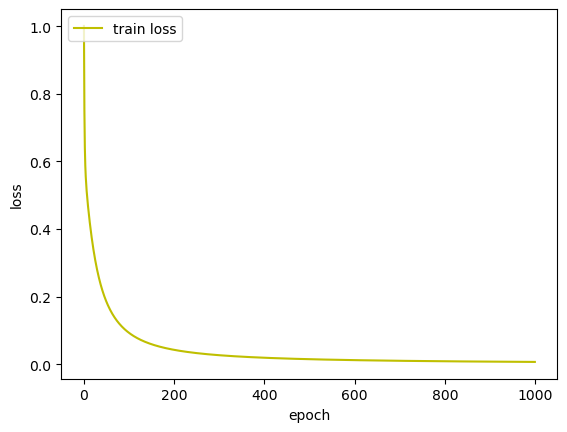

In [2]:
# 학습과정 표시하기 
import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots()

loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper left')

plt.show()

In [5]:
import os 

print(os.getcwd())

# 학습된 모델을 h5파일로 저장한다.
perceptron.save(os.getcwd()+'/model/single_perceptron_model.h5')
print("Saved model to disk !!!")

D:\PyCKUAI\202302VI\ch02
Saved model to disk !!!


In [6]:
# 필요한 패키지와 모듈을 불러오기 

import os
from tensorflow.keras.models import load_model

model = load_model(os.getcwd()+'/model/single_perceptron_model.h5')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 3         
                                                                 
Total params: 3
Trainable params: 3
Non-trainable params: 0
_________________________________________________________________


In [7]:
# OR 데이터 구축
x = [[0.0,0.0],[0.0,1.0],[1.0,0.0],[1.0,1.0]]
y = [[-1],[1],[1],[1]]

# 학습된 신경망으로 예측 
res = model.predict(x)
print(res)
#1/1 [==============================] - 0s 38ms/step
#[[-0.87554234]
# [ 0.92240846]
# [ 0.9224073 ]
# [ 0.99978375]]

# 실행 결과 첫 번째 샘플은 음수, 나머지 3개는 모두 양수로 4개 샘플을 옳게 인식함을 확인 할 수 있다(레이블 y와 동일한 인식값 출력). 

1/1 [==============================] - 0s 79ms/step
[[-0.8755613 ]
 [ 0.92241883]
 [ 0.92242014]
 [ 0.9997839 ]]


### 3) 케라스를 사용한 퍼셉트론 프로그래밍 : 활성화 함수 - sigmoid

In [1]:
# 케라스를 사용한 퍼셉트론 프로그래밍  
# - keras 클래스는 models, layers, optimizers 하위 클래스가 있다. 
# - models 클래스 : Sequential과 Functional API 모델 제작 방식 제공 
# - layers 클래스 : 다양한 종류의 층 제공 
# - optimizers 클래스 : 다양한 종류의 옵티마이저 제공 

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# OR 데이터 구축
x = [[0.0,0.0],[0.0,1.0],[1.0,0.0],[1.0,1.0]]
y = [[0],[1],[1],[1]]

n_input = 2     # 2개 입력 노드 수 
n_output = 1    # 1개 노드 수 

# 신경망 구조 설계 
# model 클래스는 Sequential을 불러와서 층을 한 줄로 쌓는 데 사용한다. 
# layers 클래스는 인전합 두 층이 완전연결된 경우에 쓰는 Dense 클래스로 퍼센트론 층이 한 번만 쌓는다.  
perceptron = Sequential()
perceptron.add(Dense(units=n_output,activation='sigmoid',input_shape=(n_input,),
                     kernel_initializer='random_uniform',bias_initializer='zeros'))

# 신경망 학습 
perceptron.compile(loss='mse',optimizer=SGD(learning_rate=0.1),metrics=['mse'])
hist = perceptron.fit(x,y,epochs=1000,verbose=2)

# 학습된 신경망으로 예측 
res = perceptron.predict(x)
print(res)
#[[0.30270243]
# [0.8283713 ]
# [0.82839626]
# [0.9817091 ]]

# 실행 결과 첫 번째 샘플은 0, 나머지 3개는 모두 1로 4개 샘플을 옳게 인식함을 확인 할 수 있다(레이블 y와 동일한 인식값 출력).

Epoch 1/1000
1/1 - 1s - loss: 0.2457 - mse: 0.2457 - 563ms/epoch - 563ms/step
Epoch 2/1000
1/1 - 0s - loss: 0.2412 - mse: 0.2412 - 6ms/epoch - 6ms/step
Epoch 3/1000
1/1 - 0s - loss: 0.2369 - mse: 0.2369 - 5ms/epoch - 5ms/step
Epoch 4/1000
1/1 - 0s - loss: 0.2327 - mse: 0.2327 - 5ms/epoch - 5ms/step
Epoch 5/1000
1/1 - 0s - loss: 0.2287 - mse: 0.2287 - 6ms/epoch - 6ms/step
Epoch 6/1000
1/1 - 0s - loss: 0.2249 - mse: 0.2249 - 6ms/epoch - 6ms/step
Epoch 7/1000
1/1 - 0s - loss: 0.2212 - mse: 0.2212 - 6ms/epoch - 6ms/step
Epoch 8/1000
1/1 - 0s - loss: 0.2177 - mse: 0.2177 - 6ms/epoch - 6ms/step
Epoch 9/1000
1/1 - 0s - loss: 0.2143 - mse: 0.2143 - 7ms/epoch - 7ms/step
Epoch 10/1000
1/1 - 0s - loss: 0.2111 - mse: 0.2111 - 6ms/epoch - 6ms/step
Epoch 11/1000
1/1 - 0s - loss: 0.2080 - mse: 0.2080 - 5ms/epoch - 5ms/step
Epoch 12/1000
1/1 - 0s - loss: 0.2050 - mse: 0.2050 - 6ms/epoch - 6ms/step
Epoch 13/1000
1/1 - 0s - loss: 0.2022 - mse: 0.2022 - 6ms/epoch - 6ms/step
Epoch 14/1000
1/1 - 0s - loss:

1/1 - 0s - loss: 0.1252 - mse: 0.1252 - 6ms/epoch - 6ms/step
Epoch 111/1000
1/1 - 0s - loss: 0.1250 - mse: 0.1250 - 5ms/epoch - 5ms/step
Epoch 112/1000
1/1 - 0s - loss: 0.1247 - mse: 0.1247 - 6ms/epoch - 6ms/step
Epoch 113/1000
1/1 - 0s - loss: 0.1245 - mse: 0.1245 - 7ms/epoch - 7ms/step
Epoch 114/1000
1/1 - 0s - loss: 0.1242 - mse: 0.1242 - 5ms/epoch - 5ms/step
Epoch 115/1000
1/1 - 0s - loss: 0.1239 - mse: 0.1239 - 5ms/epoch - 5ms/step
Epoch 116/1000
1/1 - 0s - loss: 0.1237 - mse: 0.1237 - 6ms/epoch - 6ms/step
Epoch 117/1000
1/1 - 0s - loss: 0.1234 - mse: 0.1234 - 5ms/epoch - 5ms/step
Epoch 118/1000
1/1 - 0s - loss: 0.1232 - mse: 0.1232 - 5ms/epoch - 5ms/step
Epoch 119/1000
1/1 - 0s - loss: 0.1229 - mse: 0.1229 - 6ms/epoch - 6ms/step
Epoch 120/1000
1/1 - 0s - loss: 0.1227 - mse: 0.1227 - 6ms/epoch - 6ms/step
Epoch 121/1000
1/1 - 0s - loss: 0.1225 - mse: 0.1225 - 5ms/epoch - 5ms/step
Epoch 122/1000
1/1 - 0s - loss: 0.1222 - mse: 0.1222 - 5ms/epoch - 5ms/step
Epoch 123/1000
1/1 - 0s - l

Epoch 218/1000
1/1 - 0s - loss: 0.1030 - mse: 0.1030 - 14ms/epoch - 14ms/step
Epoch 219/1000
1/1 - 0s - loss: 0.1028 - mse: 0.1028 - 7ms/epoch - 7ms/step
Epoch 220/1000
1/1 - 0s - loss: 0.1027 - mse: 0.1027 - 6ms/epoch - 6ms/step
Epoch 221/1000
1/1 - 0s - loss: 0.1025 - mse: 0.1025 - 7ms/epoch - 7ms/step
Epoch 222/1000
1/1 - 0s - loss: 0.1023 - mse: 0.1023 - 7ms/epoch - 7ms/step
Epoch 223/1000
1/1 - 0s - loss: 0.1022 - mse: 0.1022 - 7ms/epoch - 7ms/step
Epoch 224/1000
1/1 - 0s - loss: 0.1020 - mse: 0.1020 - 5ms/epoch - 5ms/step
Epoch 225/1000
1/1 - 0s - loss: 0.1018 - mse: 0.1018 - 5ms/epoch - 5ms/step
Epoch 226/1000
1/1 - 0s - loss: 0.1016 - mse: 0.1016 - 5ms/epoch - 5ms/step
Epoch 227/1000
1/1 - 0s - loss: 0.1015 - mse: 0.1015 - 5ms/epoch - 5ms/step
Epoch 228/1000
1/1 - 0s - loss: 0.1013 - mse: 0.1013 - 14ms/epoch - 14ms/step
Epoch 229/1000
1/1 - 0s - loss: 0.1011 - mse: 0.1011 - 7ms/epoch - 7ms/step
Epoch 230/1000
1/1 - 0s - loss: 0.1010 - mse: 0.1010 - 5ms/epoch - 5ms/step
Epoch 23

Epoch 326/1000
1/1 - 0s - loss: 0.0864 - mse: 0.0864 - 5ms/epoch - 5ms/step
Epoch 327/1000
1/1 - 0s - loss: 0.0863 - mse: 0.0863 - 6ms/epoch - 6ms/step
Epoch 328/1000
1/1 - 0s - loss: 0.0862 - mse: 0.0862 - 6ms/epoch - 6ms/step
Epoch 329/1000
1/1 - 0s - loss: 0.0860 - mse: 0.0860 - 7ms/epoch - 7ms/step
Epoch 330/1000
1/1 - 0s - loss: 0.0859 - mse: 0.0859 - 6ms/epoch - 6ms/step
Epoch 331/1000
1/1 - 0s - loss: 0.0858 - mse: 0.0858 - 6ms/epoch - 6ms/step
Epoch 332/1000
1/1 - 0s - loss: 0.0856 - mse: 0.0856 - 8ms/epoch - 8ms/step
Epoch 333/1000
1/1 - 0s - loss: 0.0855 - mse: 0.0855 - 7ms/epoch - 7ms/step
Epoch 334/1000
1/1 - 0s - loss: 0.0854 - mse: 0.0854 - 5ms/epoch - 5ms/step
Epoch 335/1000
1/1 - 0s - loss: 0.0852 - mse: 0.0852 - 5ms/epoch - 5ms/step
Epoch 336/1000
1/1 - 0s - loss: 0.0851 - mse: 0.0851 - 6ms/epoch - 6ms/step
Epoch 337/1000
1/1 - 0s - loss: 0.0850 - mse: 0.0850 - 5ms/epoch - 5ms/step
Epoch 338/1000
1/1 - 0s - loss: 0.0848 - mse: 0.0848 - 5ms/epoch - 5ms/step
Epoch 339/10

Epoch 434/1000
1/1 - 0s - loss: 0.0735 - mse: 0.0735 - 6ms/epoch - 6ms/step
Epoch 435/1000
1/1 - 0s - loss: 0.0734 - mse: 0.0734 - 5ms/epoch - 5ms/step
Epoch 436/1000
1/1 - 0s - loss: 0.0732 - mse: 0.0732 - 5ms/epoch - 5ms/step
Epoch 437/1000
1/1 - 0s - loss: 0.0731 - mse: 0.0731 - 6ms/epoch - 6ms/step
Epoch 438/1000
1/1 - 0s - loss: 0.0730 - mse: 0.0730 - 6ms/epoch - 6ms/step
Epoch 439/1000
1/1 - 0s - loss: 0.0729 - mse: 0.0729 - 6ms/epoch - 6ms/step
Epoch 440/1000
1/1 - 0s - loss: 0.0728 - mse: 0.0728 - 8ms/epoch - 8ms/step
Epoch 441/1000
1/1 - 0s - loss: 0.0727 - mse: 0.0727 - 6ms/epoch - 6ms/step
Epoch 442/1000
1/1 - 0s - loss: 0.0726 - mse: 0.0726 - 6ms/epoch - 6ms/step
Epoch 443/1000
1/1 - 0s - loss: 0.0725 - mse: 0.0725 - 7ms/epoch - 7ms/step
Epoch 444/1000
1/1 - 0s - loss: 0.0724 - mse: 0.0724 - 7ms/epoch - 7ms/step
Epoch 445/1000
1/1 - 0s - loss: 0.0723 - mse: 0.0723 - 6ms/epoch - 6ms/step
Epoch 446/1000
1/1 - 0s - loss: 0.0722 - mse: 0.0722 - 6ms/epoch - 6ms/step
Epoch 447/10

Epoch 542/1000
1/1 - 0s - loss: 0.0632 - mse: 0.0632 - 7ms/epoch - 7ms/step
Epoch 543/1000
1/1 - 0s - loss: 0.0632 - mse: 0.0632 - 6ms/epoch - 6ms/step
Epoch 544/1000
1/1 - 0s - loss: 0.0631 - mse: 0.0631 - 5ms/epoch - 5ms/step
Epoch 545/1000
1/1 - 0s - loss: 0.0630 - mse: 0.0630 - 5ms/epoch - 5ms/step
Epoch 546/1000
1/1 - 0s - loss: 0.0629 - mse: 0.0629 - 5ms/epoch - 5ms/step
Epoch 547/1000
1/1 - 0s - loss: 0.0628 - mse: 0.0628 - 5ms/epoch - 5ms/step
Epoch 548/1000
1/1 - 0s - loss: 0.0627 - mse: 0.0627 - 6ms/epoch - 6ms/step
Epoch 549/1000
1/1 - 0s - loss: 0.0627 - mse: 0.0627 - 6ms/epoch - 6ms/step
Epoch 550/1000
1/1 - 0s - loss: 0.0626 - mse: 0.0626 - 5ms/epoch - 5ms/step
Epoch 551/1000
1/1 - 0s - loss: 0.0625 - mse: 0.0625 - 6ms/epoch - 6ms/step
Epoch 552/1000
1/1 - 0s - loss: 0.0624 - mse: 0.0624 - 6ms/epoch - 6ms/step
Epoch 553/1000
1/1 - 0s - loss: 0.0623 - mse: 0.0623 - 6ms/epoch - 6ms/step
Epoch 554/1000
1/1 - 0s - loss: 0.0622 - mse: 0.0622 - 6ms/epoch - 6ms/step
Epoch 555/10

Epoch 650/1000
1/1 - 0s - loss: 0.0551 - mse: 0.0551 - 6ms/epoch - 6ms/step
Epoch 651/1000
1/1 - 0s - loss: 0.0550 - mse: 0.0550 - 5ms/epoch - 5ms/step
Epoch 652/1000
1/1 - 0s - loss: 0.0550 - mse: 0.0550 - 6ms/epoch - 6ms/step
Epoch 653/1000
1/1 - 0s - loss: 0.0549 - mse: 0.0549 - 5ms/epoch - 5ms/step
Epoch 654/1000
1/1 - 0s - loss: 0.0548 - mse: 0.0548 - 6ms/epoch - 6ms/step
Epoch 655/1000
1/1 - 0s - loss: 0.0548 - mse: 0.0548 - 6ms/epoch - 6ms/step
Epoch 656/1000
1/1 - 0s - loss: 0.0547 - mse: 0.0547 - 6ms/epoch - 6ms/step
Epoch 657/1000
1/1 - 0s - loss: 0.0546 - mse: 0.0546 - 5ms/epoch - 5ms/step
Epoch 658/1000
1/1 - 0s - loss: 0.0546 - mse: 0.0546 - 7ms/epoch - 7ms/step
Epoch 659/1000
1/1 - 0s - loss: 0.0545 - mse: 0.0545 - 6ms/epoch - 6ms/step
Epoch 660/1000
1/1 - 0s - loss: 0.0544 - mse: 0.0544 - 6ms/epoch - 6ms/step
Epoch 661/1000
1/1 - 0s - loss: 0.0544 - mse: 0.0544 - 6ms/epoch - 6ms/step
Epoch 662/1000
1/1 - 0s - loss: 0.0543 - mse: 0.0543 - 6ms/epoch - 6ms/step
Epoch 663/10

Epoch 758/1000
1/1 - 0s - loss: 0.0485 - mse: 0.0485 - 5ms/epoch - 5ms/step
Epoch 759/1000
1/1 - 0s - loss: 0.0485 - mse: 0.0485 - 5ms/epoch - 5ms/step
Epoch 760/1000
1/1 - 0s - loss: 0.0484 - mse: 0.0484 - 6ms/epoch - 6ms/step
Epoch 761/1000
1/1 - 0s - loss: 0.0484 - mse: 0.0484 - 6ms/epoch - 6ms/step
Epoch 762/1000
1/1 - 0s - loss: 0.0483 - mse: 0.0483 - 6ms/epoch - 6ms/step
Epoch 763/1000
1/1 - 0s - loss: 0.0483 - mse: 0.0483 - 6ms/epoch - 6ms/step
Epoch 764/1000
1/1 - 0s - loss: 0.0482 - mse: 0.0482 - 5ms/epoch - 5ms/step
Epoch 765/1000
1/1 - 0s - loss: 0.0482 - mse: 0.0482 - 5ms/epoch - 5ms/step
Epoch 766/1000
1/1 - 0s - loss: 0.0481 - mse: 0.0481 - 5ms/epoch - 5ms/step
Epoch 767/1000
1/1 - 0s - loss: 0.0481 - mse: 0.0481 - 6ms/epoch - 6ms/step
Epoch 768/1000
1/1 - 0s - loss: 0.0480 - mse: 0.0480 - 6ms/epoch - 6ms/step
Epoch 769/1000
1/1 - 0s - loss: 0.0479 - mse: 0.0479 - 6ms/epoch - 6ms/step
Epoch 770/1000
1/1 - 0s - loss: 0.0479 - mse: 0.0479 - 5ms/epoch - 5ms/step
Epoch 771/10

Epoch 866/1000
1/1 - 0s - loss: 0.0432 - mse: 0.0432 - 6ms/epoch - 6ms/step
Epoch 867/1000
1/1 - 0s - loss: 0.0431 - mse: 0.0431 - 6ms/epoch - 6ms/step
Epoch 868/1000
1/1 - 0s - loss: 0.0431 - mse: 0.0431 - 6ms/epoch - 6ms/step
Epoch 869/1000
1/1 - 0s - loss: 0.0430 - mse: 0.0430 - 6ms/epoch - 6ms/step
Epoch 870/1000
1/1 - 0s - loss: 0.0430 - mse: 0.0430 - 5ms/epoch - 5ms/step
Epoch 871/1000
1/1 - 0s - loss: 0.0429 - mse: 0.0429 - 6ms/epoch - 6ms/step
Epoch 872/1000
1/1 - 0s - loss: 0.0429 - mse: 0.0429 - 6ms/epoch - 6ms/step
Epoch 873/1000
1/1 - 0s - loss: 0.0429 - mse: 0.0429 - 6ms/epoch - 6ms/step
Epoch 874/1000
1/1 - 0s - loss: 0.0428 - mse: 0.0428 - 5ms/epoch - 5ms/step
Epoch 875/1000
1/1 - 0s - loss: 0.0428 - mse: 0.0428 - 5ms/epoch - 5ms/step
Epoch 876/1000
1/1 - 0s - loss: 0.0427 - mse: 0.0427 - 10ms/epoch - 10ms/step
Epoch 877/1000
1/1 - 0s - loss: 0.0427 - mse: 0.0427 - 6ms/epoch - 6ms/step
Epoch 878/1000
1/1 - 0s - loss: 0.0426 - mse: 0.0426 - 6ms/epoch - 6ms/step
Epoch 879/

Epoch 974/1000
1/1 - 0s - loss: 0.0387 - mse: 0.0387 - 5ms/epoch - 5ms/step
Epoch 975/1000
1/1 - 0s - loss: 0.0387 - mse: 0.0387 - 6ms/epoch - 6ms/step
Epoch 976/1000
1/1 - 0s - loss: 0.0386 - mse: 0.0386 - 5ms/epoch - 5ms/step
Epoch 977/1000
1/1 - 0s - loss: 0.0386 - mse: 0.0386 - 0s/epoch - 0s/step
Epoch 978/1000
1/1 - 0s - loss: 0.0386 - mse: 0.0386 - 11ms/epoch - 11ms/step
Epoch 979/1000
1/1 - 0s - loss: 0.0385 - mse: 0.0385 - 5ms/epoch - 5ms/step
Epoch 980/1000
1/1 - 0s - loss: 0.0385 - mse: 0.0385 - 5ms/epoch - 5ms/step
Epoch 981/1000
1/1 - 0s - loss: 0.0384 - mse: 0.0384 - 6ms/epoch - 6ms/step
Epoch 982/1000
1/1 - 0s - loss: 0.0384 - mse: 0.0384 - 5ms/epoch - 5ms/step
Epoch 983/1000
1/1 - 0s - loss: 0.0384 - mse: 0.0384 - 6ms/epoch - 6ms/step
Epoch 984/1000
1/1 - 0s - loss: 0.0383 - mse: 0.0383 - 6ms/epoch - 6ms/step
Epoch 985/1000
1/1 - 0s - loss: 0.0383 - mse: 0.0383 - 6ms/epoch - 6ms/step
Epoch 986/1000
1/1 - 0s - loss: 0.0383 - mse: 0.0383 - 6ms/epoch - 6ms/step
Epoch 987/10

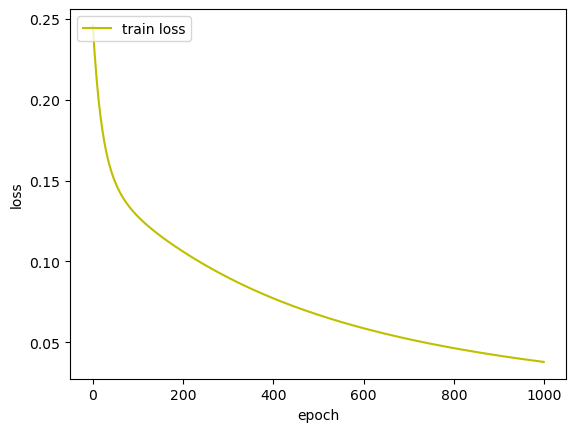

In [2]:
# 학습과정 표시하기 
import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots()

loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper left')

plt.show()

In [3]:
import os 

print(os.getcwd())

# 학습된 모델을 h5파일로 저장한다.
perceptron.save(os.getcwd()+'/model/single_perceptron_sigmoid_model.h5')
print("Saved model to disk !!!")

D:\PyCKUAI\202302VI\ch02
Saved model to disk !!!


In [4]:
# 필요한 패키지와 모듈을 불러오기 

import os
from tensorflow.keras.models import load_model

model = load_model(os.getcwd()+'/model/single_perceptron_sigmoid_model.h5')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 3         
                                                                 
Total params: 3
Trainable params: 3
Non-trainable params: 0
_________________________________________________________________


In [5]:
# OR 데이터 구축
x = [[0.0,0.0],[0.0,1.0],[1.0,0.0],[1.0,1.0]]
y = [[0],[1],[1],[1]]

# 학습된 신경망으로 예측 
res = model.predict(x)
print(res)
#1/1 [==============================] - 0s 38ms/step
#[[0.30270243]
# [0.8283713 ]
# [0.82839626]
# [0.9817091 ]]

# 실행 결과 첫 번째 샘플은 0, 나머지 3개는 모두 1로 4개 샘플을 옳게 인식함을 확인 할 수 있다(레이블 y와 동일한 인식값 출력). 

1/1 [==============================] - 0s 114ms/step
[[0.30270243]
 [0.8283713 ]
 [0.82839626]
 [0.9817091 ]]


###  4) 케라스를 사용한 퍼셉트론 프로그래밍 : XOR Gate

### 활성화 함수 : sigmoid 

In [6]:
# 케라스를 사용한 퍼셉트론 프로그래밍  
# - keras 클래스는 models, layers, optimizers 하위 클래스가 있다. 
# - models 클래스 : Sequential과 Functional API 모델 제작 방식 제공 
# - layers 클래스 : 다양한 종류의 층 제공 
# - optimizers 클래스 : 다양한 종류의 옵티마이저 제공 

# loss(손실): 평균 제곱 오차(Mean Squared Error, MSE)의 약자로 기대출력에서 실제출력을 뺀 뒤에 제곱한 값을 평균하는 것이다.

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import numpy as np

# XOR data
x = np.array([[1, 1], [1, 0], [0, 1], [0, 0]])
y = np.array([[0], [1], [1], [0]])

n_input = 2     # 2개 입력 노드 수 
n_output = 1    # 1개 노드 수 

model = Sequential([
    Dense(units=n_input, activation='sigmoid', input_shape=(n_input,)), 
    Dense(units=n_output, activation='sigmoid')     
])

model.compile(optimizer=SGD(learning_rate=0.1), loss='mse')
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 2)                 6         
                                                                 
 dense_2 (Dense)             (None, 1)                 3         
                                                                 
Total params: 9
Trainable params: 9
Non-trainable params: 0
_________________________________________________________________


In [7]:
# 모델 학습 

hist = model.fit(x, y, epochs=4000, batch_size=1, verbose=2)

# 학습된 신경망으로 예측 
res = model.predict(x)
print(res)
#[[0.08131691]
# [0.8988338 ]
# [0.8996865 ]
# [0.09134696]]

Epoch 1/4000
4/4 - 0s - loss: 0.3189 - 405ms/epoch - 101ms/step
Epoch 2/4000
4/4 - 0s - loss: 0.3129 - 23ms/epoch - 6ms/step
Epoch 3/4000
4/4 - 0s - loss: 0.3074 - 0s/epoch - 0s/step
Epoch 4/4000
4/4 - 0s - loss: 0.3020 - 0s/epoch - 0s/step
Epoch 5/4000
4/4 - 0s - loss: 0.2969 - 0s/epoch - 0s/step
Epoch 6/4000
4/4 - 0s - loss: 0.2922 - 13ms/epoch - 3ms/step
Epoch 7/4000
4/4 - 0s - loss: 0.2879 - 0s/epoch - 0s/step
Epoch 8/4000
4/4 - 0s - loss: 0.2842 - 0s/epoch - 0s/step
Epoch 9/4000
4/4 - 0s - loss: 0.2808 - 13ms/epoch - 3ms/step
Epoch 10/4000
4/4 - 0s - loss: 0.2777 - 0s/epoch - 0s/step
Epoch 11/4000
4/4 - 0s - loss: 0.2751 - 13ms/epoch - 3ms/step
Epoch 12/4000
4/4 - 0s - loss: 0.2726 - 0s/epoch - 0s/step
Epoch 13/4000
4/4 - 0s - loss: 0.2701 - 13ms/epoch - 3ms/step
Epoch 14/4000
4/4 - 0s - loss: 0.2682 - 0s/epoch - 0s/step
Epoch 15/4000
4/4 - 0s - loss: 0.2666 - 576us/epoch - 144us/step
Epoch 16/4000
4/4 - 0s - loss: 0.2651 - 13ms/epoch - 3ms/step
Epoch 17/4000
4/4 - 0s - loss: 0.26

Epoch 135/4000
4/4 - 0s - loss: 0.2552 - 10ms/epoch - 3ms/step
Epoch 136/4000
4/4 - 0s - loss: 0.2551 - 2ms/epoch - 615us/step
Epoch 137/4000
4/4 - 0s - loss: 0.2552 - 4ms/epoch - 937us/step
Epoch 138/4000
4/4 - 0s - loss: 0.2552 - 10ms/epoch - 2ms/step
Epoch 139/4000
4/4 - 0s - loss: 0.2552 - 4ms/epoch - 1ms/step
Epoch 140/4000
4/4 - 0s - loss: 0.2552 - 10ms/epoch - 3ms/step
Epoch 141/4000
4/4 - 0s - loss: 0.2552 - 0s/epoch - 0s/step
Epoch 142/4000
4/4 - 0s - loss: 0.2552 - 13ms/epoch - 3ms/step
Epoch 143/4000
4/4 - 0s - loss: 0.2552 - 1ms/epoch - 368us/step
Epoch 144/4000
4/4 - 0s - loss: 0.2552 - 12ms/epoch - 3ms/step
Epoch 145/4000
4/4 - 0s - loss: 0.2552 - 0s/epoch - 0s/step
Epoch 146/4000
4/4 - 0s - loss: 0.2552 - 13ms/epoch - 3ms/step
Epoch 147/4000
4/4 - 0s - loss: 0.2552 - 0s/epoch - 0s/step
Epoch 148/4000
4/4 - 0s - loss: 0.2552 - 4ms/epoch - 957us/step
Epoch 149/4000
4/4 - 0s - loss: 0.2552 - 0s/epoch - 0s/step
Epoch 150/4000
4/4 - 0s - loss: 0.2552 - 3ms/epoch - 717us/step


4/4 - 0s - loss: 0.2550 - 5ms/epoch - 1ms/step
Epoch 267/4000
4/4 - 0s - loss: 0.2551 - 8ms/epoch - 2ms/step
Epoch 268/4000
4/4 - 0s - loss: 0.2551 - 4ms/epoch - 1ms/step
Epoch 269/4000
4/4 - 0s - loss: 0.2551 - 9ms/epoch - 2ms/step
Epoch 270/4000
4/4 - 0s - loss: 0.2551 - 0s/epoch - 0s/step
Epoch 271/4000
4/4 - 0s - loss: 0.2551 - 3ms/epoch - 678us/step
Epoch 272/4000
4/4 - 0s - loss: 0.2550 - 10ms/epoch - 2ms/step
Epoch 273/4000
4/4 - 0s - loss: 0.2550 - 2ms/epoch - 471us/step
Epoch 274/4000
4/4 - 0s - loss: 0.2550 - 11ms/epoch - 3ms/step
Epoch 275/4000
4/4 - 0s - loss: 0.2551 - 0s/epoch - 0s/step
Epoch 276/4000
4/4 - 0s - loss: 0.2551 - 13ms/epoch - 3ms/step
Epoch 277/4000
4/4 - 0s - loss: 0.2551 - 0s/epoch - 0s/step
Epoch 278/4000
4/4 - 0s - loss: 0.2551 - 13ms/epoch - 3ms/step
Epoch 279/4000
4/4 - 0s - loss: 0.2550 - 0s/epoch - 0s/step
Epoch 280/4000
4/4 - 0s - loss: 0.2550 - 4ms/epoch - 992us/step
Epoch 281/4000
4/4 - 0s - loss: 0.2551 - 9ms/epoch - 2ms/step
Epoch 282/4000
4/4 - 

4/4 - 0s - loss: 0.2549 - 5ms/epoch - 1ms/step
Epoch 398/4000
4/4 - 0s - loss: 0.2550 - 8ms/epoch - 2ms/step
Epoch 399/4000
4/4 - 0s - loss: 0.2550 - 7ms/epoch - 2ms/step
Epoch 400/4000
4/4 - 0s - loss: 0.2550 - 5ms/epoch - 1ms/step
Epoch 401/4000
4/4 - 0s - loss: 0.2549 - 9ms/epoch - 2ms/step
Epoch 402/4000
4/4 - 0s - loss: 0.2550 - 2ms/epoch - 385us/step
Epoch 403/4000
4/4 - 0s - loss: 0.2550 - 11ms/epoch - 3ms/step
Epoch 404/4000
4/4 - 0s - loss: 0.2550 - 1ms/epoch - 283us/step
Epoch 405/4000
4/4 - 0s - loss: 0.2550 - 13ms/epoch - 3ms/step
Epoch 406/4000
4/4 - 0s - loss: 0.2550 - 8ms/epoch - 2ms/step
Epoch 407/4000
4/4 - 0s - loss: 0.2550 - 4ms/epoch - 890us/step
Epoch 408/4000
4/4 - 0s - loss: 0.2550 - 9ms/epoch - 2ms/step
Epoch 409/4000
4/4 - 0s - loss: 0.2549 - 2ms/epoch - 577us/step
Epoch 410/4000
4/4 - 0s - loss: 0.2550 - 12ms/epoch - 3ms/step
Epoch 411/4000
4/4 - 0s - loss: 0.2550 - 391us/epoch - 98us/step
Epoch 412/4000
4/4 - 0s - loss: 0.2550 - 4ms/epoch - 1ms/step
Epoch 413

Epoch 529/4000
4/4 - 0s - loss: 0.2549 - 9ms/epoch - 2ms/step
Epoch 530/4000
4/4 - 0s - loss: 0.2548 - 3ms/epoch - 810us/step
Epoch 531/4000
4/4 - 0s - loss: 0.2549 - 8ms/epoch - 2ms/step
Epoch 532/4000
4/4 - 0s - loss: 0.2548 - 0s/epoch - 0s/step
Epoch 533/4000
4/4 - 0s - loss: 0.2549 - 13ms/epoch - 3ms/step
Epoch 534/4000
4/4 - 0s - loss: 0.2548 - 0s/epoch - 0s/step
Epoch 535/4000
4/4 - 0s - loss: 0.2549 - 4ms/epoch - 975us/step
Epoch 536/4000
4/4 - 0s - loss: 0.2549 - 9ms/epoch - 2ms/step
Epoch 537/4000
4/4 - 0s - loss: 0.2549 - 5ms/epoch - 1ms/step
Epoch 538/4000
4/4 - 0s - loss: 0.2549 - 9ms/epoch - 2ms/step
Epoch 539/4000
4/4 - 0s - loss: 0.2549 - 1ms/epoch - 317us/step
Epoch 540/4000
4/4 - 0s - loss: 0.2549 - 13ms/epoch - 3ms/step
Epoch 541/4000
4/4 - 0s - loss: 0.2549 - 0s/epoch - 0s/step
Epoch 542/4000
4/4 - 0s - loss: 0.2548 - 13ms/epoch - 3ms/step
Epoch 543/4000
4/4 - 0s - loss: 0.2548 - 0s/epoch - 0s/step
Epoch 544/4000
4/4 - 0s - loss: 0.2549 - 4ms/epoch - 1ms/step
Epoch 5

...

Epoch 3387/4000
4/4 - 0s - loss: 0.0138 - 6ms/epoch - 2ms/step
Epoch 3388/4000
4/4 - 0s - loss: 0.0138 - 5ms/epoch - 1ms/step
Epoch 3389/4000
4/4 - 0s - loss: 0.0138 - 7ms/epoch - 2ms/step
Epoch 3390/4000
4/4 - 0s - loss: 0.0138 - 902us/epoch - 226us/step
Epoch 3391/4000
4/4 - 0s - loss: 0.0138 - 11ms/epoch - 3ms/step
Epoch 3392/4000
4/4 - 0s - loss: 0.0138 - 2ms/epoch - 512us/step
Epoch 3393/4000
4/4 - 0s - loss: 0.0137 - 5ms/epoch - 1ms/step
Epoch 3394/4000
4/4 - 0s - loss: 0.0137 - 0s/epoch - 0s/step
Epoch 3395/4000
4/4 - 0s - loss: 0.0137 - 4ms/epoch - 965us/step
Epoch 3396/4000
4/4 - 0s - loss: 0.0137 - 9ms/epoch - 2ms/step
Epoch 3397/4000
4/4 - 0s - loss: 0.0137 - 2ms/epoch - 581us/step
Epoch 3398/4000
4/4 - 0s - loss: 0.0137 - 11ms/epoch - 3ms/step
Epoch 3399/4000
4/4 - 0s - loss: 0.0137 - 0s/epoch - 0s/step
Epoch 3400/4000
4/4 - 0s - loss: 0.0137 - 5ms/epoch - 1ms/step
Epoch 3401/4000
4/4 - 0s - loss: 0.0136 - 10ms/epoch - 2ms/step
Epoch 3402/4000
4/4 - 0s - loss: 0.0136 - 1ms/

Epoch 3516/4000
4/4 - 0s - loss: 0.0124 - 6ms/epoch - 2ms/step
Epoch 3517/4000
4/4 - 0s - loss: 0.0124 - 5ms/epoch - 1ms/step
Epoch 3518/4000
4/4 - 0s - loss: 0.0124 - 3ms/epoch - 652us/step
Epoch 3519/4000
4/4 - 0s - loss: 0.0124 - 0s/epoch - 0s/step
Epoch 3520/4000
4/4 - 0s - loss: 0.0124 - 5ms/epoch - 1ms/step
Epoch 3521/4000
4/4 - 0s - loss: 0.0124 - 8ms/epoch - 2ms/step
Epoch 3522/4000
4/4 - 0s - loss: 0.0123 - 4ms/epoch - 1ms/step
Epoch 3523/4000
4/4 - 0s - loss: 0.0123 - 9ms/epoch - 2ms/step
Epoch 3524/4000
4/4 - 0s - loss: 0.0123 - 3ms/epoch - 806us/step
Epoch 3525/4000
4/4 - 0s - loss: 0.0123 - 11ms/epoch - 3ms/step
Epoch 3526/4000
4/4 - 0s - loss: 0.0123 - 4ms/epoch - 1ms/step
Epoch 3527/4000
4/4 - 0s - loss: 0.0123 - 9ms/epoch - 2ms/step
Epoch 3528/4000
4/4 - 0s - loss: 0.0123 - 0s/epoch - 0s/step
Epoch 3529/4000
4/4 - 0s - loss: 0.0123 - 5ms/epoch - 1ms/step
Epoch 3530/4000
4/4 - 0s - loss: 0.0123 - 9ms/epoch - 2ms/step
Epoch 3531/4000
4/4 - 0s - loss: 0.0123 - 3ms/epoch - 

Epoch 3645/4000
4/4 - 0s - loss: 0.0112 - 6ms/epoch - 1ms/step
Epoch 3646/4000
4/4 - 0s - loss: 0.0112 - 6ms/epoch - 2ms/step
Epoch 3647/4000
4/4 - 0s - loss: 0.0112 - 6ms/epoch - 1ms/step
Epoch 3648/4000
4/4 - 0s - loss: 0.0112 - 7ms/epoch - 2ms/step
Epoch 3649/4000
4/4 - 0s - loss: 0.0112 - 2ms/epoch - 518us/step
Epoch 3650/4000
4/4 - 0s - loss: 0.0112 - 11ms/epoch - 3ms/step
Epoch 3651/4000
4/4 - 0s - loss: 0.0112 - 0s/epoch - 0s/step
Epoch 3652/4000
4/4 - 0s - loss: 0.0112 - 12ms/epoch - 3ms/step
Epoch 3653/4000
4/4 - 0s - loss: 0.0112 - 2ms/epoch - 405us/step
Epoch 3654/4000
4/4 - 0s - loss: 0.0112 - 5ms/epoch - 1ms/step
Epoch 3655/4000
4/4 - 0s - loss: 0.0111 - 8ms/epoch - 2ms/step
Epoch 3656/4000
4/4 - 0s - loss: 0.0111 - 6ms/epoch - 1ms/step
Epoch 3657/4000
4/4 - 0s - loss: 0.0111 - 9ms/epoch - 2ms/step
Epoch 3658/4000
4/4 - 0s - loss: 0.0111 - 2ms/epoch - 623us/step
Epoch 3659/4000
4/4 - 0s - loss: 0.0111 - 12ms/epoch - 3ms/step
Epoch 3660/4000
4/4 - 0s - loss: 0.0111 - 0s/epo

Epoch 3774/4000
4/4 - 0s - loss: 0.0102 - 15ms/epoch - 4ms/step
Epoch 3775/4000
4/4 - 0s - loss: 0.0102 - 5ms/epoch - 1ms/step
Epoch 3776/4000
4/4 - 0s - loss: 0.0102 - 5ms/epoch - 1ms/step
Epoch 3777/4000
4/4 - 0s - loss: 0.0102 - 6ms/epoch - 2ms/step
Epoch 3778/4000
4/4 - 0s - loss: 0.0102 - 6ms/epoch - 1ms/step
Epoch 3779/4000
4/4 - 0s - loss: 0.0102 - 956us/epoch - 239us/step
Epoch 3780/4000
4/4 - 0s - loss: 0.0102 - 11ms/epoch - 3ms/step
Epoch 3781/4000
4/4 - 0s - loss: 0.0102 - 734us/epoch - 183us/step
Epoch 3782/4000
4/4 - 0s - loss: 0.0102 - 11ms/epoch - 3ms/step
Epoch 3783/4000
4/4 - 0s - loss: 0.0102 - 0s/epoch - 0s/step
Epoch 3784/4000
4/4 - 0s - loss: 0.0102 - 13ms/epoch - 3ms/step
Epoch 3785/4000
4/4 - 0s - loss: 0.0102 - 0s/epoch - 0s/step
Epoch 3786/4000
4/4 - 0s - loss: 0.0102 - 5ms/epoch - 1ms/step
Epoch 3787/4000
4/4 - 0s - loss: 0.0102 - 8ms/epoch - 2ms/step
Epoch 3788/4000
4/4 - 0s - loss: 0.0101 - 5ms/epoch - 1ms/step
Epoch 3789/4000
4/4 - 0s - loss: 0.0101 - 8ms/e

4/4 - 0s - loss: 0.0094 - 5ms/epoch - 1ms/step
Epoch 3904/4000
4/4 - 0s - loss: 0.0094 - 8ms/epoch - 2ms/step
Epoch 3905/4000
4/4 - 0s - loss: 0.0094 - 3ms/epoch - 841us/step
Epoch 3906/4000
4/4 - 0s - loss: 0.0094 - 5ms/epoch - 1ms/step
Epoch 3907/4000
4/4 - 0s - loss: 0.0094 - 0s/epoch - 0s/step
Epoch 3908/4000
4/4 - 0s - loss: 0.0094 - 5ms/epoch - 1ms/step
Epoch 3909/4000
4/4 - 0s - loss: 0.0094 - 7ms/epoch - 2ms/step
Epoch 3910/4000
4/4 - 0s - loss: 0.0094 - 4ms/epoch - 1ms/step
Epoch 3911/4000
4/4 - 0s - loss: 0.0094 - 10ms/epoch - 3ms/step
Epoch 3912/4000
4/4 - 0s - loss: 0.0093 - 1ms/epoch - 335us/step
Epoch 3913/4000
4/4 - 0s - loss: 0.0093 - 11ms/epoch - 3ms/step
Epoch 3914/4000
4/4 - 0s - loss: 0.0093 - 984us/epoch - 246us/step
Epoch 3915/4000
4/4 - 0s - loss: 0.0093 - 13ms/epoch - 3ms/step
Epoch 3916/4000
4/4 - 0s - loss: 0.0093 - 0s/epoch - 0s/step
Epoch 3917/4000
4/4 - 0s - loss: 0.0093 - 4ms/epoch - 1ms/step
Epoch 3918/4000
4/4 - 0s - loss: 0.0093 - 9ms/epoch - 2ms/step
E

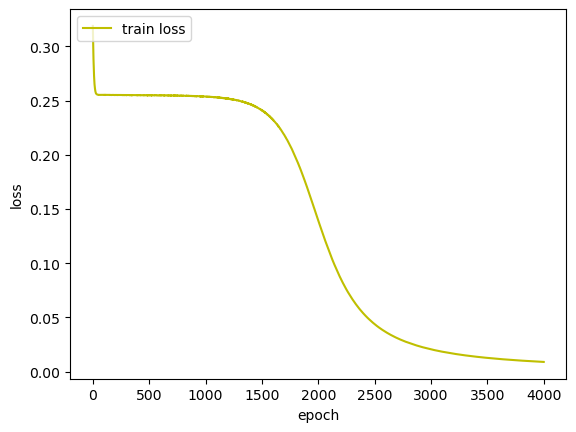

In [8]:
# 학습과정 시각화하기 

import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots()

loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper left')

plt.show()

In [9]:
# 학습된 모델을 h5파일로 저장한다.

import os

model.save(os.getcwd()+'/model/single_perceptron_xor_sigmoid_model.h5')
print("Saved model to disk !!!")

Saved model to disk !!!


In [10]:
# 필요한 패키지와 모듈을 불러오기 

import os
from tensorflow.keras.models import load_model

model = load_model(os.getcwd()+'/model/single_perceptron_xor_sigmoid_model.h5')
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 2)                 6         
                                                                 
 dense_2 (Dense)             (None, 1)                 3         
                                                                 
Total params: 9
Trainable params: 9
Non-trainable params: 0
_________________________________________________________________


In [11]:
# XOR data
x = np.array([[1, 1], [1, 0], [0, 1], [0, 0]])
y = np.array([[0], [1], [1], [0]])

# 학습된 신경망으로 예측 
res = model.predict(x)
print(res)

1/1 [==============================] - 0s 83ms/step
[[0.08131691]
 [0.8988338 ]
 [0.8996865 ]
 [0.09134696]]


### 활성화 함수 : tanh

In [12]:
# 케라스를 사용한 퍼셉트론 프로그래밍  
# - keras 클래스는 models, layers, optimizers 하위 클래스가 있다. 
# - models 클래스 : Sequential과 Functional API 모델 제작 방식 제공 
# - layers 클래스 : 다양한 종류의 층 제공 
# - optimizers 클래스 : 다양한 종류의 옵티마이저 제공 

# loss(손실): 평균 제곱 오차(Mean Squared Error, MSE)의 약자로 기대출력에서 실제출력을 뺀 뒤에 제곱한 값을 평균하는 것이다.

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import numpy as np

# XOR data
x = np.array([[1, 1], [1, 0], [0, 1], [0, 0]])
y = np.array([[-1], [1], [1], [-1]])

n_input = 2     # 2개 입력 노드 수 
n_output = 1    # 1개 노드 수 

model = Sequential([
    Dense(units=n_input, activation='tanh', input_shape=(n_input,)), 
    Dense(units=n_output, activation='tanh')     
])

model.compile(optimizer=SGD(learning_rate=0.1), loss='mse')
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 2)                 6         
                                                                 
 dense_4 (Dense)             (None, 1)                 3         
                                                                 
Total params: 9
Trainable params: 9
Non-trainable params: 0
_________________________________________________________________


In [13]:
# 모델 학습 

hist = model.fit(x, y, epochs=4000, batch_size=1, verbose=2)

# 학습된 신경망으로 예측 
res = model.predict(x)
print(res)
#[[-0.98554146]
# [ 0.9894027 ]
# [ 0.98929596]
# [-0.98668236]]

Epoch 1/4000
4/4 - 0s - loss: 1.9306 - 445ms/epoch - 111ms/step
Epoch 2/4000
4/4 - 0s - loss: 1.8382 - 9ms/epoch - 2ms/step
Epoch 3/4000
4/4 - 0s - loss: 1.3997 - 9ms/epoch - 2ms/step
Epoch 4/4000
4/4 - 0s - loss: 1.4797 - 14ms/epoch - 3ms/step
Epoch 5/4000
4/4 - 0s - loss: 1.3512 - 13ms/epoch - 3ms/step
Epoch 6/4000
4/4 - 0s - loss: 1.0963 - 7ms/epoch - 2ms/step
Epoch 7/4000
4/4 - 0s - loss: 1.2399 - 2ms/epoch - 526us/step
Epoch 8/4000
4/4 - 0s - loss: 1.1447 - 4ms/epoch - 973us/step
Epoch 9/4000
4/4 - 0s - loss: 1.0830 - 0s/epoch - 0s/step
Epoch 10/4000
4/4 - 0s - loss: 0.8954 - 2ms/epoch - 481us/step
Epoch 11/4000
4/4 - 0s - loss: 1.0396 - 13ms/epoch - 3ms/step
Epoch 12/4000
4/4 - 0s - loss: 1.0800 - 1ms/epoch - 306us/step
Epoch 13/4000
4/4 - 0s - loss: 1.0446 - 11ms/epoch - 3ms/step
Epoch 14/4000
4/4 - 0s - loss: 0.9980 - 0s/epoch - 0s/step
Epoch 15/4000
4/4 - 0s - loss: 0.9714 - 3ms/epoch - 827us/step
Epoch 16/4000
4/4 - 0s - loss: 0.8621 - 10ms/epoch - 3ms/step
Epoch 17/4000
4/4 

Epoch 134/4000
4/4 - 0s - loss: 0.0096 - 6ms/epoch - 1ms/step
Epoch 135/4000
4/4 - 0s - loss: 0.0094 - 0s/epoch - 0s/step
Epoch 136/4000
4/4 - 0s - loss: 0.0093 - 5ms/epoch - 1ms/step
Epoch 137/4000
4/4 - 0s - loss: 0.0092 - 8ms/epoch - 2ms/step
Epoch 138/4000
4/4 - 0s - loss: 0.0091 - 0s/epoch - 0s/step
Epoch 139/4000
4/4 - 0s - loss: 0.0090 - 13ms/epoch - 3ms/step
Epoch 140/4000
4/4 - 0s - loss: 0.0089 - 0s/epoch - 0s/step
Epoch 141/4000
4/4 - 0s - loss: 0.0088 - 2ms/epoch - 623us/step
Epoch 142/4000
4/4 - 0s - loss: 0.0087 - 12ms/epoch - 3ms/step
Epoch 143/4000
4/4 - 0s - loss: 0.0086 - 0s/epoch - 0s/step
Epoch 144/4000
4/4 - 0s - loss: 0.0085 - 14ms/epoch - 3ms/step
Epoch 145/4000
4/4 - 0s - loss: 0.0084 - 0s/epoch - 0s/step
Epoch 146/4000
4/4 - 0s - loss: 0.0083 - 2ms/epoch - 616us/step
Epoch 147/4000
4/4 - 0s - loss: 0.0082 - 11ms/epoch - 3ms/step
Epoch 148/4000
4/4 - 0s - loss: 0.0081 - 2ms/epoch - 387us/step
Epoch 149/4000
4/4 - 0s - loss: 0.0080 - 12ms/epoch - 3ms/step
Epoch 1

Epoch 265/4000
4/4 - 0s - loss: 0.0035 - 8ms/epoch - 2ms/step
Epoch 266/4000
4/4 - 0s - loss: 0.0035 - 5ms/epoch - 1ms/step
Epoch 267/4000
4/4 - 0s - loss: 0.0035 - 9ms/epoch - 2ms/step
Epoch 268/4000
4/4 - 0s - loss: 0.0034 - 0s/epoch - 0s/step
Epoch 269/4000
4/4 - 0s - loss: 0.0034 - 14ms/epoch - 3ms/step
Epoch 270/4000
4/4 - 0s - loss: 0.0034 - 0s/epoch - 0s/step
Epoch 271/4000
4/4 - 0s - loss: 0.0034 - 14ms/epoch - 3ms/step
Epoch 272/4000
4/4 - 0s - loss: 0.0034 - 0s/epoch - 0s/step
Epoch 273/4000
4/4 - 0s - loss: 0.0034 - 15ms/epoch - 4ms/step
Epoch 274/4000
4/4 - 0s - loss: 0.0033 - 8ms/epoch - 2ms/step
Epoch 275/4000
4/4 - 0s - loss: 0.0033 - 2ms/epoch - 438us/step
Epoch 276/4000
4/4 - 0s - loss: 0.0033 - 11ms/epoch - 3ms/step
Epoch 277/4000
4/4 - 0s - loss: 0.0033 - 0s/epoch - 0s/step
Epoch 278/4000
4/4 - 0s - loss: 0.0033 - 13ms/epoch - 3ms/step
Epoch 279/4000
4/4 - 0s - loss: 0.0033 - 0s/epoch - 0s/step
Epoch 280/4000
4/4 - 0s - loss: 0.0032 - 13ms/epoch - 3ms/step
Epoch 281/

Epoch 397/4000
4/4 - 0s - loss: 0.0021 - 4ms/epoch - 1ms/step
Epoch 398/4000
4/4 - 0s - loss: 0.0021 - 9ms/epoch - 2ms/step
Epoch 399/4000
4/4 - 0s - loss: 0.0021 - 3ms/epoch - 648us/step
Epoch 400/4000
4/4 - 0s - loss: 0.0021 - 10ms/epoch - 2ms/step
Epoch 401/4000
4/4 - 0s - loss: 0.0021 - 0s/epoch - 0s/step
Epoch 402/4000
4/4 - 0s - loss: 0.0020 - 14ms/epoch - 3ms/step
Epoch 403/4000
4/4 - 0s - loss: 0.0020 - 0s/epoch - 0s/step
Epoch 404/4000
4/4 - 0s - loss: 0.0020 - 14ms/epoch - 3ms/step
Epoch 405/4000
4/4 - 0s - loss: 0.0020 - 12ms/epoch - 3ms/step
Epoch 406/4000
4/4 - 0s - loss: 0.0020 - 2ms/epoch - 493us/step
Epoch 407/4000
4/4 - 0s - loss: 0.0020 - 12ms/epoch - 3ms/step
Epoch 408/4000
4/4 - 0s - loss: 0.0020 - 0s/epoch - 0s/step
Epoch 409/4000
4/4 - 0s - loss: 0.0020 - 4ms/epoch - 975us/step
Epoch 410/4000
4/4 - 0s - loss: 0.0020 - 9ms/epoch - 2ms/step
Epoch 411/4000
4/4 - 0s - loss: 0.0020 - 2ms/epoch - 541us/step
Epoch 412/4000
4/4 - 0s - loss: 0.0020 - 13ms/epoch - 3ms/step


Epoch 528/4000
4/4 - 0s - loss: 0.0015 - 717us/epoch - 179us/step
Epoch 529/4000
4/4 - 0s - loss: 0.0015 - 6ms/epoch - 1ms/step
Epoch 530/4000
4/4 - 0s - loss: 0.0015 - 8ms/epoch - 2ms/step
Epoch 531/4000
4/4 - 0s - loss: 0.0015 - 1ms/epoch - 357us/step
Epoch 532/4000
4/4 - 0s - loss: 0.0015 - 12ms/epoch - 3ms/step
Epoch 533/4000
4/4 - 0s - loss: 0.0015 - 987us/epoch - 247us/step
Epoch 534/4000
4/4 - 0s - loss: 0.0014 - 13ms/epoch - 3ms/step
Epoch 535/4000
4/4 - 0s - loss: 0.0014 - 12ms/epoch - 3ms/step
Epoch 536/4000
4/4 - 0s - loss: 0.0014 - 0s/epoch - 0s/step
Epoch 537/4000
4/4 - 0s - loss: 0.0014 - 14ms/epoch - 3ms/step
Epoch 538/4000
4/4 - 0s - loss: 0.0014 - 0s/epoch - 0s/step
Epoch 539/4000
4/4 - 0s - loss: 0.0014 - 2ms/epoch - 612us/step
Epoch 540/4000
4/4 - 0s - loss: 0.0014 - 12ms/epoch - 3ms/step
Epoch 541/4000
4/4 - 0s - loss: 0.0014 - 994us/epoch - 248us/step
Epoch 542/4000
4/4 - 0s - loss: 0.0014 - 11ms/epoch - 3ms/step
Epoch 543/4000
4/4 - 0s - loss: 0.0014 - 13ms/epoch 

...

Epoch 3501/4000
4/4 - 0s - loss: 1.7697e-04 - 16ms/epoch - 4ms/step
Epoch 3502/4000
4/4 - 0s - loss: 1.7692e-04 - 0s/epoch - 0s/step
Epoch 3503/4000
4/4 - 0s - loss: 1.7687e-04 - 16ms/epoch - 4ms/step
Epoch 3504/4000
4/4 - 0s - loss: 1.7681e-04 - 0s/epoch - 0s/step
Epoch 3505/4000
4/4 - 0s - loss: 1.7676e-04 - 16ms/epoch - 4ms/step
Epoch 3506/4000
4/4 - 0s - loss: 1.7671e-04 - 0s/epoch - 0s/step
Epoch 3507/4000
4/4 - 0s - loss: 1.7665e-04 - 16ms/epoch - 4ms/step
Epoch 3508/4000
4/4 - 0s - loss: 1.7660e-04 - 0s/epoch - 0s/step
Epoch 3509/4000
4/4 - 0s - loss: 1.7654e-04 - 16ms/epoch - 4ms/step
Epoch 3510/4000
4/4 - 0s - loss: 1.7649e-04 - 0s/epoch - 0s/step
Epoch 3511/4000
4/4 - 0s - loss: 1.7644e-04 - 16ms/epoch - 4ms/step
Epoch 3512/4000
4/4 - 0s - loss: 1.7638e-04 - 0s/epoch - 0s/step
Epoch 3513/4000
4/4 - 0s - loss: 1.7633e-04 - 16ms/epoch - 4ms/step
Epoch 3514/4000
4/4 - 0s - loss: 1.7627e-04 - 0s/epoch - 0s/step
Epoch 3515/4000
4/4 - 0s - loss: 1.7622e-04 - 0s/epoch - 0s/step
Epoc

Epoch 3625/4000
4/4 - 0s - loss: 1.7050e-04 - 0s/epoch - 0s/step
Epoch 3626/4000
4/4 - 0s - loss: 1.7045e-04 - 16ms/epoch - 4ms/step
Epoch 3627/4000
4/4 - 0s - loss: 1.7040e-04 - 0s/epoch - 0s/step
Epoch 3628/4000
4/4 - 0s - loss: 1.7035e-04 - 16ms/epoch - 4ms/step
Epoch 3629/4000
4/4 - 0s - loss: 1.7030e-04 - 0s/epoch - 0s/step
Epoch 3630/4000
4/4 - 0s - loss: 1.7025e-04 - 16ms/epoch - 4ms/step
Epoch 3631/4000
4/4 - 0s - loss: 1.7020e-04 - 0s/epoch - 0s/step
Epoch 3632/4000
4/4 - 0s - loss: 1.7015e-04 - 16ms/epoch - 4ms/step
Epoch 3633/4000
4/4 - 0s - loss: 1.7010e-04 - 0s/epoch - 0s/step
Epoch 3634/4000
4/4 - 0s - loss: 1.7005e-04 - 16ms/epoch - 4ms/step
Epoch 3635/4000
4/4 - 0s - loss: 1.7000e-04 - 0s/epoch - 0s/step
Epoch 3636/4000
4/4 - 0s - loss: 1.6995e-04 - 16ms/epoch - 4ms/step
Epoch 3637/4000
4/4 - 0s - loss: 1.6990e-04 - 16ms/epoch - 4ms/step
Epoch 3638/4000
4/4 - 0s - loss: 1.6985e-04 - 0s/epoch - 0s/step
Epoch 3639/4000
4/4 - 0s - loss: 1.6980e-04 - 16ms/epoch - 4ms/step
E

Epoch 3749/4000
4/4 - 0s - loss: 1.6447e-04 - 16ms/epoch - 4ms/step
Epoch 3750/4000
4/4 - 0s - loss: 1.6443e-04 - 0s/epoch - 0s/step
Epoch 3751/4000
4/4 - 0s - loss: 1.6438e-04 - 0s/epoch - 0s/step
Epoch 3752/4000
4/4 - 0s - loss: 1.6433e-04 - 0s/epoch - 0s/step
Epoch 3753/4000
4/4 - 0s - loss: 1.6429e-04 - 0s/epoch - 0s/step
Epoch 3754/4000
4/4 - 0s - loss: 1.6424e-04 - 16ms/epoch - 4ms/step
Epoch 3755/4000
4/4 - 0s - loss: 1.6419e-04 - 0s/epoch - 0s/step
Epoch 3756/4000
4/4 - 0s - loss: 1.6415e-04 - 16ms/epoch - 4ms/step
Epoch 3757/4000
4/4 - 0s - loss: 1.6410e-04 - 0s/epoch - 0s/step
Epoch 3758/4000
4/4 - 0s - loss: 1.6405e-04 - 16ms/epoch - 4ms/step
Epoch 3759/4000
4/4 - 0s - loss: 1.6401e-04 - 0s/epoch - 0s/step
Epoch 3760/4000
4/4 - 0s - loss: 1.6396e-04 - 16ms/epoch - 4ms/step
Epoch 3761/4000
4/4 - 0s - loss: 1.6391e-04 - 0s/epoch - 0s/step
Epoch 3762/4000
4/4 - 0s - loss: 1.6387e-04 - 0s/epoch - 0s/step
Epoch 3763/4000
4/4 - 0s - loss: 1.6382e-04 - 0s/epoch - 0s/step
Epoch 3764

Epoch 3873/4000
4/4 - 0s - loss: 1.5885e-04 - 0s/epoch - 0s/step
Epoch 3874/4000
4/4 - 0s - loss: 1.5881e-04 - 16ms/epoch - 4ms/step
Epoch 3875/4000
4/4 - 0s - loss: 1.5876e-04 - 0s/epoch - 0s/step
Epoch 3876/4000
4/4 - 0s - loss: 1.5872e-04 - 16ms/epoch - 4ms/step
Epoch 3877/4000
4/4 - 0s - loss: 1.5868e-04 - 0s/epoch - 0s/step
Epoch 3878/4000
4/4 - 0s - loss: 1.5863e-04 - 16ms/epoch - 4ms/step
Epoch 3879/4000
4/4 - 0s - loss: 1.5859e-04 - 0s/epoch - 0s/step
Epoch 3880/4000
4/4 - 0s - loss: 1.5854e-04 - 16ms/epoch - 4ms/step
Epoch 3881/4000
4/4 - 0s - loss: 1.5850e-04 - 0s/epoch - 0s/step
Epoch 3882/4000
4/4 - 0s - loss: 1.5846e-04 - 16ms/epoch - 4ms/step
Epoch 3883/4000
4/4 - 0s - loss: 1.5841e-04 - 0s/epoch - 0s/step
Epoch 3884/4000
4/4 - 0s - loss: 1.5837e-04 - 0s/epoch - 0s/step
Epoch 3885/4000
4/4 - 0s - loss: 1.5833e-04 - 16ms/epoch - 4ms/step
Epoch 3886/4000
4/4 - 0s - loss: 1.5828e-04 - 0s/epoch - 0s/step
Epoch 3887/4000
4/4 - 0s - loss: 1.5824e-04 - 16ms/epoch - 4ms/step
Epoc

Epoch 3997/4000
4/4 - 0s - loss: 1.5359e-04 - 0s/epoch - 0s/step
Epoch 3998/4000
4/4 - 0s - loss: 1.5355e-04 - 0s/epoch - 0s/step
Epoch 3999/4000
4/4 - 0s - loss: 1.5351e-04 - 16ms/epoch - 4ms/step
Epoch 4000/4000
4/4 - 0s - loss: 1.5347e-04 - 0s/epoch - 0s/step
1/1 [==============================] - 0s 78ms/step
[[-0.98554146]
 [ 0.9894027 ]
 [ 0.98929596]
 [-0.98668236]]


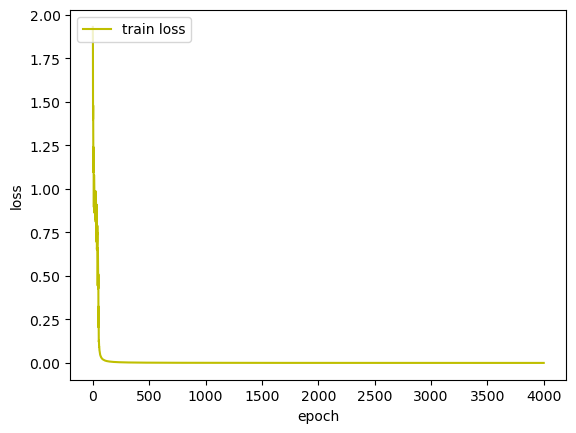

In [14]:
# 학습과정 시각화하기 

import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots()

loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper left')

plt.show()

In [15]:
# 학습된 모델을 h5파일로 저장한다.

import os

model.save(os.getcwd()+'/model/single_perceptron_xor_tanh_model.h5')
print("Saved model to disk !!!")

Saved model to disk !!!


In [16]:
# 필요한 패키지와 모듈을 불러오기 

import os
from tensorflow.keras.models import load_model

model = load_model(os.getcwd()+'/model/single_perceptron_xor_tanh_model.h5')
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 2)                 6         
                                                                 
 dense_4 (Dense)             (None, 1)                 3         
                                                                 
Total params: 9
Trainable params: 9
Non-trainable params: 0
_________________________________________________________________


In [17]:
# XOR data
x = np.array([[1, 1], [1, 0], [0, 1], [0, 0]])
y = np.array([[-1], [1], [1], [-1]])

# 학습된 신경망으로 예측 
res = model.predict(x)
print(res)

1/1 [==============================] - 0s 90ms/step
[[-0.98554146]
 [ 0.9894027 ]
 [ 0.98929596]
 [-0.98668236]]
